# The Wasserstein distance

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/distances/wasserstein.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

Think of each distribution as a pile of sand with total mass 1. The **Wasserstein distance** is the least
amount of work needed to reshape one pile into the other, where moving mass $m$ over a distance $d$ costs
$m\,d$ (for $W_1$) or $m\,d^{\,r}$ (for $W_r$). It is also called the *earth mover's distance*.

On the real line there is no need to search over ways of moving the sand: the cheapest plan moves the mass
in order, so the $u$-quantile of $P$ goes to the $u$-quantile of $Q$. With CDFs $F$, $G$ and quantile
functions $F^{-1}$, $G^{-1}$ this gives

$$W_r(P,Q) = \Big(\int_0^1 \big|F^{-1}(u) - G^{-1}(u)\big|^r\,du\Big)^{1/r},
\qquad
W_1(P,Q) = \int_{-\infty}^{\infty} \big|F(x) - G(x)\big|\,dx .$$

Its main properties:

* it is a true distance (a metric): symmetric, zero only when $P = Q$, and it satisfies the triangle inequality;
* it is measured **in the units of $x$**: it says how far, on average, mass has to move;
* it needs only CDFs or quantiles, not densities, so it works for discrete distributions and for samples just as well.

In [1]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-40, 40, 16001)                    # grid in x
u = (np.arange(20000) + 0.5) / 20000               # grid in (0, 1) for quantile levels

def normal_pdf(x, mu=0.0, sigma=1.0):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / np.sqrt(2 * np.pi * sigma**2)

def cdf(pdf):
    # CDF on the grid x, by integrating the density (trapezoidal rule)
    F = np.concatenate([[0], np.cumsum((pdf[1:] + pdf[:-1]) / 2 * np.diff(x))])
    return F / F[-1]

def quantile(F, levels):
    # F^{-1}(u) = smallest grid point x with F(x) >= u
    return x[np.minimum(np.searchsorted(F, levels), len(x) - 1)]

def w1(F, G):
    return np.trapezoid(np.abs(F - G), x)        # area between the CDFs

def wr(F, G, r):
    return np.mean(np.abs(quantile(F, u) - quantile(G, u))**r) ** (1 / r)

## 1. Two pictures of $W_1$

Take $p = \mathcal{N}(0,1)$ and $q = \mathcal{N}(1.5,1)$. On the left, $W_1$ is the area between the two CDFs,
measured vertically. On the right, it is the area between the two quantile functions, measured horizontally:
the mass at level $u$ moves from $F^{-1}(u)$ to $G^{-1}(u)$. Both shaded regions have the same area.

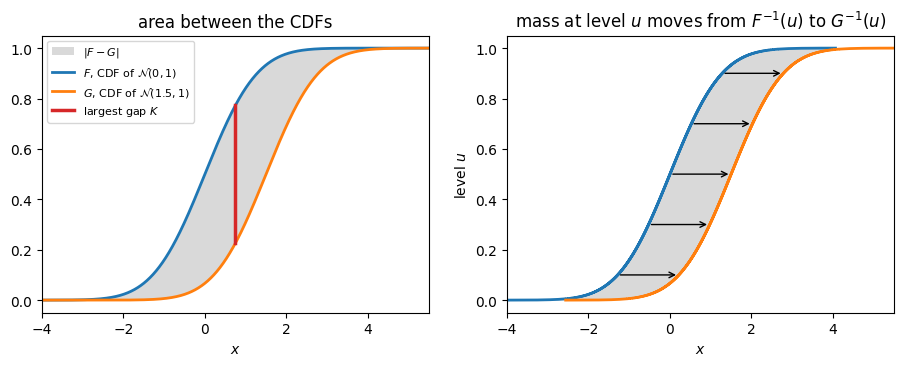

area between CDFs:            W1 = 1.5000
area between quantile curves: W1 = 1.5000
largest vertical gap:          K = 0.5467


In [2]:
F, G = cdf(normal_pdf(x, 0, 1)), cdf(normal_pdf(x, 1.5, 1))
Qf, Qg = quantile(F, u), quantile(G, u)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.6))
ax0.fill_between(x, F, G, color="0.85", lw=0, label="$|F-G|$")
ax0.plot(x, F, "C0", lw=2, label="$F$, CDF of $\\mathcal{N}(0,1)$")
ax0.plot(x, G, "C1", lw=2, label="$G$, CDF of $\\mathcal{N}(1.5,1)$")
k = np.argmax(np.abs(F - G))                                   # where the vertical gap is largest
ax0.plot([x[k], x[k]], [G[k], F[k]], "C3", lw=2.5, label="largest gap $K$")
ax0.set_xlim(-4, 5.5); ax0.set_xlabel("$x$"); ax0.set_title("area between the CDFs"); ax0.legend(loc="upper left", fontsize=8)
ax1.fill_betweenx(u, Qf, Qg, color="0.85", lw=0)
ax1.plot(Qf, u, "C0", lw=2); ax1.plot(Qg, u, "C1", lw=2)
for level in [0.1, 0.3, 0.5, 0.7, 0.9]:                        # where the mass at level u goes
    i = np.searchsorted(u, level)
    ax1.annotate("", xy=(Qg[i], level), xytext=(Qf[i], level), arrowprops=dict(arrowstyle="->", color="k"))
ax1.set_xlim(-4, 5.5); ax1.set_xlabel("$x$"); ax1.set_ylabel("level $u$")
ax1.set_title("mass at level $u$ moves from $F^{-1}(u)$ to $G^{-1}(u)$")
plt.show()

print(f"area between CDFs:            W1 = {w1(F, G):.4f}")
print(f"area between quantile curves: W1 = {np.mean(np.abs(Qf - Qg)):.4f}")
print(f"largest vertical gap:          K = {np.abs(F - G).max():.4f}")

Every arrow has length $1.5$: a shift moves every bit of mass by the same amount. So $W_1 = 1.5$, the
size of the shift.

The red segment on the left is the **largest** vertical gap,

$$K(P,Q) = \sup_x \big|F(x) - G(x)\big|,$$

the **Kolmogorov distance**. $W_1$ adds up all the vertical gaps; $K$ keeps only the largest one. $K$ is exactly
the quantity that the DKW inequality controls when $G$ is an empirical CDF (see `../dkw.ipynb`), and it is the
statistic of the Kolmogorov–Smirnov test. Like total variation, $K$ is at most 1, and it only sees heights of the
CDFs, not how far the mass sits.

## 2. Shifts, and distributions that do not overlap

For a shift, every quantile moves by $\mu$, so $W_r\big(\mathcal{N}(0,1), \mathcal{N}(\mu,1)\big) = |\mu|$ for **every** $r$.

largest error vs |mu|:  W1 1.8e-15,  W2 0.0e+00
mu = 1:  W1 = 1.000,   K = 0.383
mu = 4:  W1 = 4.000,   K = 0.954
mu = 8:  W1 = 8.000,   K = 1.000


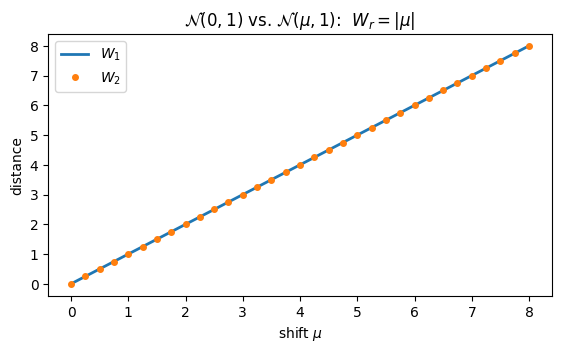

In [3]:
shifts = np.linspace(0, 8, 33)
F = cdf(normal_pdf(x, 0, 1))
W1 = np.array([w1(F, cdf(normal_pdf(x, mu, 1))) for mu in shifts])
W2 = np.array([wr(F, cdf(normal_pdf(x, mu, 1)), 2) for mu in shifts])
print(f"largest error vs |mu|:  W1 {np.abs(W1 - shifts).max():.1e},  W2 {np.abs(W2 - shifts).max():.1e}")
for mu in [1, 4, 8]:
    print(f"mu = {mu}:  W1 = {w1(F, cdf(normal_pdf(x, mu, 1))):.3f},   K = {np.abs(F - cdf(normal_pdf(x, mu, 1))).max():.3f}")

plt.figure(figsize=(6.5, 3.4))
plt.plot(shifts, W1, "C0", lw=2, label="$W_1$")
plt.plot(shifts, W2, "C1", lw=0, marker="o", ms=4, label="$W_2$")
plt.xlabel(r"shift $\mu$"); plt.ylabel("distance"); plt.legend()
plt.title(r"$\mathcal{N}(0,1)$ vs. $\mathcal{N}(\mu,1)$:  $W_r = |\mu|$")
plt.show()

The distance grows **linearly** with the shift and never levels off. It keeps measuring how far apart the
distributions are even when they no longer overlap at all. The Kolmogorov distance, in contrast, levels off at 1. Two uniforms make the point: for
$P = \text{Uniform}(0,1)$ and $Q = \text{Uniform}(a, a+1)$, every bit of mass moves by $a$, so $W_1 = a$.

In [4]:
unif = lambda lo: ((x >= lo) & (x <= lo + 1)).astype(float)
for a in [0.5, 2, 10]:
    print(f"a = {a:4}:  W1(Uniform(0,1), Uniform(a,a+1)) = {w1(cdf(unif(0)), cdf(unif(a))):.3f}")

a =  0.5:  W1(Uniform(0,1), Uniform(a,a+1)) = 0.500
a =    2:  W1(Uniform(0,1), Uniform(a,a+1)) = 2.000
a =   10:  W1(Uniform(0,1), Uniform(a,a+1)) = 10.000


## 3. Different spreads

Now keep the mean and change the spread: $P = \mathcal{N}(0,1)$, $Q = \mathcal{N}(0,\sigma^2)$. The quantiles of $Q$ are
$\sigma$ times those of $P$, so the mass at $z$ moves to $\sigma z$, a distance $|\sigma-1|\,|z|$. Averaging,

$$W_1 = |\sigma-1|\,\mathbb{E}|Z| = |\sigma-1|\sqrt{2/\pi}, \qquad W_2 = |\sigma-1|\sqrt{\mathbb{E}[Z^2]} = |\sigma-1| .$$

More generally, for any two Gaussians,
$W_2\big(\mathcal{N}(\mu_1,\sigma_1^2), \mathcal{N}(\mu_2,\sigma_2^2)\big)^2 = (\mu_1-\mu_2)^2 + (\sigma_1-\sigma_2)^2$:
the mean and the standard deviation enter on an equal footing, both in units of $x$. Check it, and check that
swapping the two distributions changes nothing:

In [5]:
rng = np.random.default_rng(166)
print(f"{'mu1':>6} {'s1':>5} {'mu2':>6} {'s2':>5} {'W2(P,Q)':>8} {'W2(Q,P)':>8} {'formula':>8}")
for _ in range(5):
    mu1, mu2 = rng.uniform(-3, 3, 2)
    s1, s2 = rng.uniform(0.5, 3, 2)
    F, G = cdf(normal_pdf(x, mu1, s1)), cdf(normal_pdf(x, mu2, s2))
    print(f"{mu1:6.2f} {s1:5.2f} {mu2:6.2f} {s2:5.2f} {wr(F, G, 2):8.4f} {wr(G, F, 2):8.4f} "
          f"{np.sqrt((mu1 - mu2)**2 + (s1 - s2)**2):8.4f}")

   mu1    s1    mu2    s2  W2(P,Q)  W2(Q,P)  formula
  1.30  2.26  -1.98  1.08   3.4885   3.4885   3.4886
  2.65  1.59   1.04  0.87   1.7680   1.7680   1.7681
 -0.98  1.34   2.62  2.90   3.9223   3.9223   3.9223
 -0.18  2.85   1.21  0.55   2.6949   2.6949   2.6950
 -2.95  2.32  -0.11  2.04   2.8574   2.8574   2.8574


## 4. From samples

Because $W_1$ only needs CDFs, it can be computed straight from data. For two samples of the same size $n$,
the cheapest plan matches the smallest value of one sample with the smallest of the other, the second
smallest with the second smallest, and so on:

$$W_1 = \frac1n\sum_{i=1}^n \big|x_{(i)} - y_{(i)}\big|,$$

where $x_{(1)} \le \dots \le x_{(n)}$ are the sorted values.

In [6]:
n = 500
xs = np.sort(rng.normal(0, 1, n))
ys = np.sort(rng.normal(1.5, 1, n))
print(f"W1 between the two samples: {np.mean(np.abs(xs - ys)):.3f}   (between the distributions: 1.5)")

W1 between the two samples: 1.556   (between the distributions: 1.5)


How close is the empirical CDF $\widehat F_n$ to the true $F$ in this distance? Draw samples of size $n$ from
$\mathcal{N}(0,1)$, compute $W_1(\widehat F_n, F) = \int |\widehat F_n(x) - F(x)|\,dx$, and average over 200 samples for each $n$.

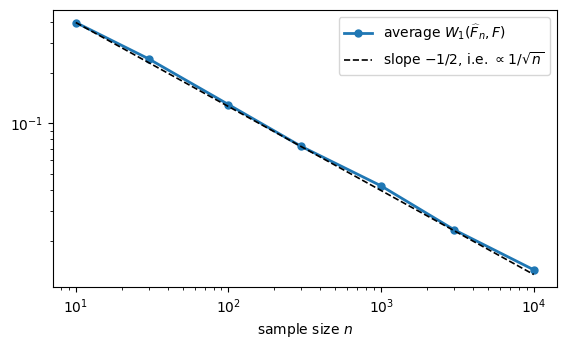

n =     10:  average W1 = 0.3975,   sqrt(n) * W1 = 1.257
n =     30:  average W1 = 0.2417,   sqrt(n) * W1 = 1.324
n =    100:  average W1 = 0.1291,   sqrt(n) * W1 = 1.291
n =    300:  average W1 = 0.0727,   sqrt(n) * W1 = 1.260
n =   1000:  average W1 = 0.0424,   sqrt(n) * W1 = 1.339
n =   3000:  average W1 = 0.0232,   sqrt(n) * W1 = 1.273
n =  10000:  average W1 = 0.0134,   sqrt(n) * W1 = 1.341


In [7]:
F = cdf(normal_pdf(x, 0, 1))
ns = np.array([10, 30, 100, 300, 1000, 3000, 10000])
avg = []
for m in ns:
    vals = []
    for _ in range(200):
        s = np.sort(rng.normal(0, 1, m))
        Fn = np.searchsorted(s, x, side="right") / m        # empirical CDF on the grid
        vals.append(w1(Fn, F))
    avg.append(np.mean(vals))
avg = np.array(avg)

plt.figure(figsize=(6.5, 3.6))
plt.loglog(ns, avg, "C0o-", lw=2, ms=5, label=r"average $W_1(\widehat F_n, F)$")
plt.loglog(ns, avg[0] * np.sqrt(ns[0] / ns), "k--", lw=1.2, label=r"slope $-1/2$, i.e. $\propto 1/\sqrt{n}$")
plt.xlabel("sample size $n$"); plt.legend()
plt.show()
for m, a in zip(ns, avg):
    print(f"n = {m:6d}:  average W1 = {a:.4f},   sqrt(n) * W1 = {np.sqrt(m) * a:.3f}")

The distance shrinks like $1/\sqrt{n}$: $\sqrt{n}\,W_1$ settles near a constant. Quadrupling the data halves the
distance, the same rate as the standard error of a sample mean, and the same rate as the DKW band in `../dkw.ipynb`.

## Things to try

* In Section 1, give $q$ a different standard deviation. Do all arrows still have the same length?
* In Section 2, compare $W_1$ and $W_2$ for $\mathcal{N}(0,1)$ against $\mathcal{N}(0,\sigma^2)$. Which is larger? (In general $W_1 \le W_2$.)
* In Section 4, use two samples of different sizes. How would you match them? (Hint: compare the empirical quantile functions.)
* Repeat the convergence experiment with a heavy-tailed distribution, such as `rng.standard_t(3, m)`.

The notebooks `lp.ipynb` and `kl.ipynb` look at two other ways to compare distributions;
`probdistance.ipynb` compares all of them on the same examples.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. Wasserman does not cover the Wasserstein distance; the empirical CDF and the quantile function it is built from are in Chapter 7 of *All of Statistics*.